# Модуль 8. Полносвязные сети и backprop

Ноутбук к [модулю 8](https://drobyshevdev.github.io/lemma/modules/08-neural-networks-and-backprop/).

Сеть пишется целиком на NumPy: прямой проход, обратный, обучение. Около семидесяти строк. PyTorch появится в следующем модуле, когда станет ясно, от чего именно он избавляет.

Ни одна формула здесь не принимается на веру: каждая проходит gradient check из модуля 4, прежде чем на ней что-то обучается.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. XOR: чего не может линейная модель

Четыре точки. Класс равен единице, когда признаки различаются. Прямой, разделяющей их, не существует.

In [2]:
X_xor = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = np.array([[0.0], [1.0], [1.0], [0.0]])

# Лучшая возможная линейная модель: решаем точно методом наименьших квадратов.
Xb = np.hstack([X_xor, np.ones((4, 1))])
w_lin = np.linalg.lstsq(Xb, y_xor, rcond=None)[0]

print("предсказания лучшей линейной модели:", (Xb @ w_lin).ravel())
print("правильные ответы:                  ", y_xor.ravel())
print("\nОна выдаёт 0.5 на все четыре точки: лучшее, что можно сделать прямой.")

предсказания лучшей линейной модели: [0.5 0.5 0.5 0.5]
правильные ответы:                   [0. 1. 1. 0.]

Она выдаёт 0.5 на все четыре точки: лучшее, что можно сделать прямой.


## 2. Слой

Прямой проход — две строки. Обратный — четыре, и все четыре выведены в тексте модуля.

In [3]:
def relu(z):        return np.maximum(0.0, z)
def relu_grad(z):   return (z > 0).astype(float)
def sigmoid(z):     return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def tanh_grad(z):   return 1.0 - np.tanh(z) ** 2

ACTIVATIONS = {
    "relu":    (relu, relu_grad),
    "tanh":    (np.tanh, tanh_grad),
    "sigmoid": (sigmoid, lambda z: sigmoid(z) * (1 - sigmoid(z))),
}

def init_params(sizes, scheme="he", seed=0):
    """Веса по слоям. Дисперсия подобрана так, чтобы сигнал не рос и не затухал."""
    rng = np.random.default_rng(seed)
    params = []
    for n_in, n_out in zip(sizes[:-1], sizes[1:]):
        if scheme == "zeros":
            W = np.zeros((n_in, n_out))
        elif scheme == "big":
            W = rng.normal(0, 3.0, (n_in, n_out))
        elif scheme == "xavier":
            W = rng.normal(0, np.sqrt(1.0 / n_in), (n_in, n_out))
        else:                                        # he
            W = rng.normal(0, np.sqrt(2.0 / n_in), (n_in, n_out))
        params.append([W, np.zeros(n_out)])
    return params

def forward(params, X, activation="relu"):
    """Возвращает предсказание и все промежуточные z и a -- они нужны назад."""
    f, _ = ACTIVATIONS[activation]
    a = X
    cache = [(None, X)]
    for i, (W, b) in enumerate(params):
        z = a @ W + b
        a = sigmoid(z) if i == len(params) - 1 else f(z)   # на выходе всегда сигмоида
        cache.append((z, a))
    return a, cache

def log_loss(pred, y):
    p = np.clip(pred, 1e-12, 1 - 1e-12)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

## 3. Обратный проход и его проверка

Три формулы из текста, переведённые в код один в один.

In [4]:
def backward(params, cache, y, activation="relu"):
    _, f_grad = ACTIVATIONS[activation]
    n = len(y)
    grads = [None] * len(params)

    # Последний слой: сигмоида плюс log loss дают ровно (a - y). То же
    # сокращение, что в модуле 4 у логистической регрессии.
    delta = (cache[-1][1] - y) / n

    for l in range(len(params) - 1, -1, -1):
        a_prev = cache[l][1]
        grads[l] = [a_prev.T @ delta, delta.sum(axis=0)]
        if l > 0:
            z_prev = cache[l][0]
            # Ошибка раскладывается назад по весам и гасится там,
            # где нейрон был в насыщении.
            delta = (delta @ params[l][0].T) * f_grad(z_prev)
    return grads

def gradient_check(params, X, y, activation="relu", h=1e-5):
    """Относительное расхождение аналитического градиента с численным."""
    pred, cache = forward(params, X, activation)
    analytic = backward(params, cache, y, activation)

    worst = 0.0
    for l, (W, b) in enumerate(params):
        num = np.zeros_like(W)
        it = np.nditer(W, flags=["multi_index"])
        while not it.finished:
            idx = it.multi_index
            old = W[idx]
            W[idx] = old + h
            plus = log_loss(forward(params, X, activation)[0], y)
            W[idx] = old - h
            minus = log_loss(forward(params, X, activation)[0], y)
            W[idx] = old
            num[idx] = (plus - minus) / (2 * h)
            it.iternext()
        rel = np.linalg.norm(analytic[l][0] - num) / (
            np.linalg.norm(analytic[l][0]) + np.linalg.norm(num) + 1e-12)
        worst = max(worst, float(rel))
    return worst

params = init_params([2, 4, 1], seed=1)
print(f"gradient check: {gradient_check(params, X_xor, y_xor):.2e}")
print("Меньше 1e-7 -- формулы верны. Теперь можно обучать.")

gradient check: 1.39e-10
Меньше 1e-7 -- формулы верны. Теперь можно обучать.


In [5]:
def broken_backward(params, cache, y, activation="relu"):
    """Та же функция с одной опечаткой: забыли транспонировать веса."""
    _, f_grad = ACTIVATIONS[activation]
    n = len(y)
    grads = [None] * len(params)
    delta = (cache[-1][1] - y) / n
    for l in range(len(params) - 1, -1, -1):
        a_prev = cache[l][1]
        grads[l] = [a_prev.T @ delta, delta.sum(axis=0)]
        if l > 0:
            delta = (delta @ params[l][0].T) * 1.0        # <- потеряли f'(z)
    return grads

# Тот же расчёт, но с испорченной функцией.
params2 = init_params([2, 4, 1], seed=1)
pred, cache = forward(params2, X_xor, "relu")
good = backward(params2, cache, y_xor, "relu")
bad = broken_backward(params2, cache, y_xor, "relu")

diff = max(float(np.abs(g[0] - b[0]).max()) for g, b in zip(good, bad))
print(f"расхождение между верной и испорченной версиями: {diff:.4f}")
print("\nСеть с такой ошибкой не падает. Она просто учится хуже,")
print("и без gradient check это не отличить от «данных мало».")

расхождение между верной и испорченной версиями: 0.0621

Сеть с такой ошибкой не падает. Она просто учится хуже,
и без gradient check это не отличить от «данных мало».


## 4. Обучение на XOR

Спуск из модуля 4, ничего нового.

In [6]:
def train(X, y, sizes, activation="relu", scheme="he", eta=0.5, steps=4000, seed=0):
    params = init_params(sizes, scheme, seed)
    history = []
    for _ in range(steps):
        pred, cache = forward(params, X, activation)
        history.append(log_loss(pred, y))
        grads = backward(params, cache, y, activation)
        for (W, b), (gW, gb) in zip(params, grads):
            W -= eta * gW
            b -= eta * gb
    return params, np.array(history)

net, hist = train(X_xor, y_xor, [2, 4, 1], eta=1.0, steps=4000, seed=1)
pred, _ = forward(net, X_xor, "relu")
print("предсказания сети:", pred.ravel().round(3))
print("правильные ответы:", y_xor.ravel())
print(f"\nпотеря: {hist[0]:.4f} -> {hist[-1]:.6f}")

предсказания сети: [0. 1. 1. 0.]
правильные ответы: [0. 1. 1. 0.]

потеря: 0.6864 -> 0.000113


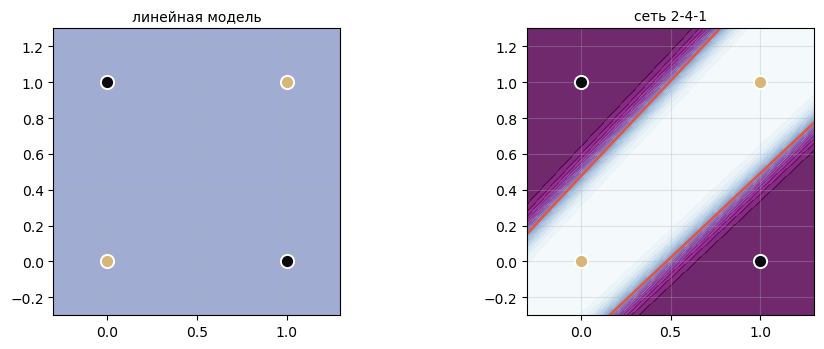

In [7]:
gx, gy = np.meshgrid(np.linspace(-0.3, 1.3, 220), np.linspace(-0.3, 1.3, 220))
grid = np.stack([gx.ravel(), gy.ravel()], axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6))

lin_surface = (np.hstack([grid, np.ones((len(grid), 1))]) @ w_lin).reshape(gx.shape)
net_surface = forward(net, grid, "relu")[0].reshape(gx.shape)

for ax, surface, title in [(ax1, lin_surface, "линейная модель"),
                           (ax2, net_surface, "сеть 2-4-1")]:
    ax.contourf(gx, gy, surface, levels=20, cmap="BuPu", alpha=0.85)
    ax.contour(gx, gy, surface, levels=[0.5], colors="#e5533c", linewidths=1.6)
    for point, label in zip(X_xor, y_xor.ravel()):
        ax.scatter(*point, s=90, zorder=5, edgecolor="white", linewidth=1.4,
                   color="#0a0b0e" if label else "#d8b678")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
plt.tight_layout(); plt.show()

Слева граница отсутствует: поверхность плоская, красной линии уровня 0.5 нет вовсе. Справа сеть согнула пространство и разделила точки.

Один скрытый слой из четырёх нейронов. Ничего, кроме композиции линейных слоёв и ReLU между ними.

**Сломайте:** уберите активацию — поставьте вместо `relu` тождественную функцию. Что станет с границей? Это и есть доказательство из задания 2.

## 5. Инициализация

Три схемы на одной задаче и одном зерне.

     схема   потеря в конце


     zeros           0.6886


       big           0.4530


        he           0.0015


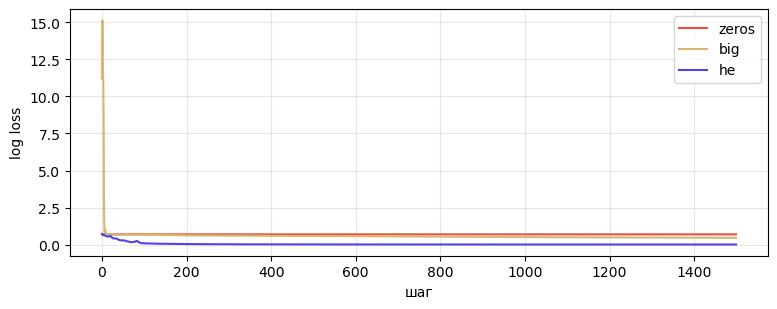

In [8]:
rng = np.random.default_rng(4)
n = 800
Xc = rng.normal(0, 1, size=(n, 6))
yc = ((Xc[:, 0] * Xc[:, 1] + 0.7 * Xc[:, 2] ** 2 - 0.5 > 0)).astype(float)[:, None]

fig, ax = plt.subplots()
print(f"{'схема':>10} {'потеря в конце':>16}")
for scheme, colour in [("zeros", "#e5533c"), ("big", "#d8b678"), ("he", "#4f46e5")]:
    _, h = train(Xc, yc, [6, 32, 16, 1], scheme=scheme, eta=0.5, steps=1500, seed=2)
    ax.plot(h, color=colour, label=scheme)
    print(f"{scheme:>10} {h[-1]:>16.4f}")
ax.set_xlabel("шаг"); ax.set_ylabel("log loss"); ax.legend()
plt.show()

In [9]:
# Почему нули не работают: все нейроны слоя остаются одинаковыми навсегда.
zero_net, _ = train(Xc, yc, [6, 32, 16, 1], scheme="zeros", eta=0.5, steps=300, seed=2)
W1 = zero_net[0][0]
print("после 300 шагов, первые 4 нейрона скрытого слоя (по 3 веса):")
print(W1[:3, :4])
print(f"\nвсе столбцы одинаковы: {np.allclose(W1, W1[:, [0]])}")
print(f"хоть один вес сдвинулся с нуля: {not np.allclose(W1, 0)}")
print("\nЗдесь даже хуже, чем симметрия. Градиент первого слоя идёт назад")
print("через веса второго, а они нулевые -- значит он тождественно ноль,")
print("и слой не двигается вообще. Ломает это только случайная инициализация.")

после 300 шагов, первые 4 нейрона скрытого слоя (по 3 веса):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

все столбцы одинаковы: True
хоть один вес сдвинулся с нуля: False

Здесь даже хуже, чем симметрия. Градиент первого слоя идёт назад
через веса второго, а они нулевые -- значит он тождественно ноль,
и слой не двигается вообще. Ломает это только случайная инициализация.


## 6. Затухание градиента

Производная сигмоиды нигде не больше 0.25. Цепное правило перемножает производные по слоям — посмотрим, что доходит до первого слоя.

In [10]:
def first_layer_gradient(depth, activation, seed=0):
    """Норма градиента первого слоя в сети заданной глубины."""
    sizes = [6] + [24] * depth + [1]
    scheme = "xavier" if activation == "sigmoid" else "he"
    params = init_params(sizes, scheme, seed)
    pred, cache = forward(params, Xc, activation)
    grads = backward(params, cache, yc, activation)
    return float(np.linalg.norm(grads[0][0]))

print(f"{'глубина':>8} {'сигмоида':>14} {'ReLU':>14} {'отношение':>12}")
for depth in [1, 3, 5, 8, 12]:
    s = first_layer_gradient(depth, "sigmoid")
    r = first_layer_gradient(depth, "relu")
    print(f"{depth:>8} {s:>14.3e} {r:>14.3e} {r / s:>12.1f}x")

 глубина       сигмоида           ReLU    отношение
       1      1.249e-02      1.946e-01         15.6x
       3      4.694e-04      1.231e-01        262.2x
       5      1.431e-05      3.861e-02       2697.5x
       8      3.198e-07      6.858e-02     214409.8x
      12      1.090e-09      1.273e-01  116723295.8x


У сигмоиды градиент первого слоя падает на порядки с каждой парой слоёв. У ReLU держится: её производная равна единице на всей положительной половине, а умножение единиц ничего не затухает.

Первые слои сигмоидной сети не учатся вовсе — не «медленно», а на уровне машинной точности. Ровно это держало глубокие сети мёртвыми до конца двухтысячных, и ReLU была не оптимизацией, а условием существования глубины.

**Сломайте:** посчитайте $0.25^{\text{глубина}}$ и сравните с колонкой сигмоиды. Сходится ли порядок величины?

## 7. Сеть против бустинга

Проверка на честность. Те же табличные данные, что в модуле 6, те же правила сравнения, что в модуле 7.

In [11]:
def make_tabular(n=1200, seed=0):
    """Ровно те же данные, что в модуле 6: пороги, взаимодействие, немного линейности."""
    rng = np.random.default_rng(seed)
    X = rng.normal(0, 1, size=(n, 5))
    y = (2.0 * (X[:, 0] > 0.5) - 1.5 * (X[:, 1] < -0.3)
         + 1.2 * (X[:, 0] > 0) * (X[:, 2] > 0) + 0.4 * X[:, 3]
         + rng.normal(0, 0.4, n))
    return X, y

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

# --- бустинг из модуля 6, сокращённо ---
def best_split(X, y):
    best, parent = (None, None, 0.0), y.var() * len(y)
    for j in range(X.shape[1]):
        for t in np.unique(np.quantile(X[:, j], np.linspace(0.05, 0.95, 24))):
            left = X[:, j] <= t
            nl = int(left.sum())
            if nl < 5 or len(y) - nl < 5:
                continue
            gain = parent - (y[left].var() * nl + y[~left].var() * (len(y) - nl))
            if gain > best[2]:
                best = (j, float(t), float(gain))
    return best

def build_tree(X, y, depth):
    if depth == 0 or len(y) < 10 or y.var() < 1e-12:
        return {"leaf": float(y.mean())}
    j, t, _ = best_split(X, y)
    if j is None:
        return {"leaf": float(y.mean())}
    m = X[:, j] <= t
    return {"f": j, "t": t, "l": build_tree(X[m], y[m], depth - 1),
            "r": build_tree(X[~m], y[~m], depth - 1)}

def predict_tree(tree, X):
    out = np.empty(len(X))
    for i, row in enumerate(X):
        node = tree
        while "leaf" not in node:
            node = node["l"] if row[node["f"]] <= node["t"] else node["r"]
        out[i] = node["leaf"]
    return out

def fit_boost(X, y, n_trees=80, lr=0.1, depth=3):
    base, pred, trees = float(y.mean()), np.full(len(y), float(y.mean())), []
    for _ in range(n_trees):
        tree = build_tree(X, y - pred, depth)
        pred += lr * predict_tree(tree, X)
        trees.append(tree)
    return base, trees, lr

def predict_boost(model, X):
    base, trees, lr = model
    out = np.full(len(X), base)
    for t in trees:
        out += lr * predict_tree(t, X)
    return out

In [12]:
def train_regression(X, y, sizes, eta=0.05, steps=3000, seed=0):
    """Та же сеть, но на выходе без сигмоиды и с квадратичной потерей."""
    params = init_params(sizes, "he", seed)
    mu, sd = X.mean(0), X.std(0)          # нормализация: модуль 4 объяснил зачем
    Xn = (X - mu) / sd
    ym, ys = y.mean(), y.std()
    yn = ((y - ym) / ys)[:, None]
    for _ in range(steps):
        a, cache = Xn, [(None, Xn)]
        for i, (W, b) in enumerate(params):
            z = a @ W + b
            a = z if i == len(params) - 1 else relu(z)
            cache.append((z, a))
        delta = 2 * (cache[-1][1] - yn) / len(yn)
        for l in range(len(params) - 1, -1, -1):
            gW = cache[l][1].T @ delta
            gb = delta.sum(axis=0)
            if l > 0:
                delta = (delta @ params[l][0].T) * relu_grad(cache[l][0])
            params[l][0] -= eta * gW
            params[l][1] -= eta * gb
    def predict(Xnew):
        a = (Xnew - mu) / sd
        for i, (W, b) in enumerate(params):
            z = a @ W + b
            a = z if i == len(params) - 1 else relu(z)
        return a.ravel() * ys + ym
    return predict

Xv, yv = make_tabular(3000, seed=99)

net_scores, boost_scores = [], []
for seed in range(5):
    Xt, yt = make_tabular(1200, seed=seed)
    net_scores.append(rmse(train_regression(Xt, yt, [5, 64, 32, 1], seed=seed)(Xv), yv))
    boost_scores.append(rmse(predict_boost(fit_boost(Xt, yt), Xv), yv))

def bootstrap_ci(values, seed=0, n_resamples=10_000):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    draws = rng.choice(values, size=(n_resamples, len(values)), replace=True)
    return np.percentile(draws.mean(axis=1), [2.5, 97.5])

print(f"{'модель':<28} {'RMSE (5 разбиений)':>20} {'95% интервал':>22}")
for name, s in [("сеть 5-64-32-1", net_scores), ("бустинг, 80 деревьев", boost_scores)]:
    lo, hi = bootstrap_ci(s)
    print(f"{name:<28} {np.mean(s):>20.3f} {f'[{lo:.3f}, {hi:.3f}]':>22}")
print(f"\nуровень шума в данных: 0.400")

модель                         RMSE (5 разбиений)           95% интервал
сеть 5-64-32-1                              0.704         [0.688, 0.721]
бустинг, 80 деревьев                        0.460         [0.449, 0.470]

уровень шума в данных: 0.400


Результат читайте по правилу перекрытия из модуля 1, а не по тому, чьё имя вам симпатичнее.

Данные табличные: пороги, взаимодействие, пять признаков, тысяча двести строк. Всё, что перечислено в модуле 6 как причина превосходства деревьев, здесь присутствует.

Вывод не в том, что сети плохие. Он в том, что **умение обучить сеть не означает, что её надо обучать**. В модуле 9 появятся изображения — там есть структура, из которой сеть извлекает пользу, и разрыв будет в другую сторону и разгромным.

**Сломайте:** дайте сети вчетверо больше шагов и вдвое больше нейронов. Сдвинется ли интервал? А теперь уберите нормализацию входов и посмотрите, что будет.

## Итог

1. Лучшая линейная модель на XOR выдаёт 0.5 на все четыре точки. Сеть из четырёх нейронов решает задачу.
2. Формулы обратного прохода приняты gradient check до обучения, а не после.
3. Потерянный множитель $f'(z)$ не роняет сеть — она просто учится хуже. Без проверки это неотличимо от «данных мало».
4. Инициализация нулями оставляет все 32 нейрона слоя буквально одинаковыми: слой работает как один.
5. Градиент первого слоя у сигмоидной сети падает на порядки с глубиной, у ReLU держится.
6. На табличных данных сеть не обыгрывает бустинг, и это ожидаемо по причинам из модуля 6.

Дальше — [модуль 9](https://drobyshevdev.github.io/lemma/programme/): свёртки, первая архитектура, которая использует структуру данных.